In [168]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import ast
import os
import re

mpl.rcParams['figure.dpi'] = 150

In [169]:
path = kagglehub.dataset_download("elahehgolrokh/data-science-job-postings-with-salaries-2025")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

In [170]:
df = pd.read_csv(full_path)
df.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [171]:
df.shape

(944, 13)

In [172]:
df.columns

Index(['job_title', 'seniority_level', 'status', 'company', 'location',
       'post_date', 'headquarter', 'industry', 'ownership', 'company_size',
       'revenue', 'salary', 'skills'],
      dtype='object')

job_title → The main keyword in the title of the posted position (e.g., Data Scientist, ML Engineer).
seniority_level → Seniority of the role (e.g., Junior, Senior, Lead).
status → Work arrangement type (Remote, Hybrid, On-site).
company → Anonymized company identifier.
location → Job location(s) mentioned in the posting.
post_date → When the job posting was listed.
headquarter → Location of the company’s headquarters.
industry → Industry sector of the company (e.g., Finance, Technology).
ownership → Ownership type (e.g., Public, Private).
company_size → Number of employees in the company.
revenue → Reported revenue of the company (if available).
salary → Annual salary in Euro, expressed as min-max or a single value
skills→ Extracted list of required or preferred skills (e.g., Python, SQL, Spark).

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB


In [174]:
columns_to_get_values = ['job_title', 'seniority_level', 'status', 'industry', 'ownership']

for i, col in enumerate(columns_to_get_values, 1):
    print(f'{i}.{col}')
    for val in df[col].unique():
        print(f'    -{val}')

1.job_title
    -data scientist
    -machine learning engineer
    -nan
    -data analyst
    -data engineer
2.seniority_level
    -senior
    -lead
    -nan
    -junior
    -midlevel
3.status
    -hybrid
    -on-site
    -nan
    -remote
4.industry
    -Retail
    -Manufacturing
    -Technology
    -Finance
    -Education
    -Healthcare
    -Energy
    -Logistics
5.ownership
    -Public
    -Private
    -nan


In [175]:
print('Number of duplicated rows:', df.duplicated().sum())

Number of duplicated rows: 0


In [176]:
def get_non_numeric_chars(data):
    not_numeric_chars = set()
    
    for val in data:
        if isinstance(val, str):
            chars = re.findall(r'[^0-9.]+', val)
            not_numeric_chars.update(chars)
    
    return not_numeric_chars

salary_non_numeric_chars = get_non_numeric_chars(df['salary'].unique())
revenue_non_numeric_chars = get_non_numeric_chars(df['revenue'].unique())
company_size_non_numeric_chars = get_non_numeric_chars(df['company_size'].unique())

print('Salary not numeric characters:', salary_non_numeric_chars)
print('revenue not numeric characters:', revenue_non_numeric_chars)
print('Company size not numeric characters:', company_size_non_numeric_chars)

Salary not numeric characters: {',', ' - €', '€'}
revenue not numeric characters: {'Private', 'Public', 'Nonprofit', 'Education', 'T', '€', 'B', 'M'}
Company size not numeric characters: {'B', ',', 'Private', '€'}


<p>This code defines a helper function to identify all non-numeric characters in a dataset column, then applies it to the <b>‘salary’</b>, <b>‘revenue’</b>, and <b>‘company_size’</b> columns. The function uses regex to extract any characters that aren’t digits or decimal points, collecting them in a set to show unique non-numeric elements (like currency symbols, separators, or text labels). This analysis helps identify what needs to be cleaned before converting these columns to numeric values.</p>

In [177]:
def clean_salary(salary):
    salary = str(salary)
    
    if pd.isnull(salary):
        return np.nan
    
    salary = salary.replace('€', '').replace(',', '').strip()
    
    if '-' in salary:
        salary_split = salary.split('-')
        min_salary = float(salary_split[0])
        max_salary = float(salary_split[1])
        midpoint_salary = (min_salary + max_salary) / 2
        
        return {'min': min_salary, 'max': max_salary, 'midpoint': midpoint_salary}
    else:
        salary = float(salary)
        return {'min': salary, 'max': salary, 'midpoint': salary}
    

def categorize_salary(salary_value):
    if pd.isna(salary_value):
        return 'Unknown'
    
    if salary_value < 50000:
        return 'Small (<€50k)'
    elif salary_value < 100000:
        return 'Medium (€50k-€100k)'
    elif salary_value < 200000:
        return 'High (€100k-€200k)'
    else:
        return 'Special (>€200k)'
    

salary_details = df['salary'].apply(lambda x: clean_salary(x))
df['min_salary'] = salary_details.apply(lambda x: x['min'])
df['max_salary'] = salary_details.apply(lambda x: x['max'])
df['midpoint_salary'] = salary_details.apply(lambda x: x['midpoint'])
df['salary_category'] = df['midpoint_salary'].apply(lambda x: categorize_salary(x))

df[['min_salary', 'max_salary', 'midpoint_salary', 'salary_category']].head()

,min_salary,max_salary,midpoint_salary,salary_category
0,100472.0,200938.0,150705.0,High (€100k-€200k)
1,118733.0,118733.0,118733.0,High (€100k-€200k)
2,94987.0,159559.0,127273.0,High (€100k-€200k)
3,112797.0,194402.0,153599.5,High (€100k-€200k)
4,114172.0,228337.0,171254.5,High (€100k-€200k)


In [178]:
def clean_revenue(revenue):
    revenue = str(revenue)
    
    if pd.isnull(revenue):
        return np.nan
    
    if revenue in ['Education', 'Nonprofit', 'Private', 'Public']:
        return np.nan
    
    revenue = str(revenue).replace('€', '').replace(',', '').strip()
    
    if 'M' in revenue:
        revenue = revenue.replace('M', 'e7')
    elif 'B' in revenue:
        revenue = revenue.replace('B', 'e9')
    elif 'T' in revenue:
        return np.nan
    
    return float(revenue)


def categorize_revenue(revenue_value):
    if pd.isna(revenue_value):
        return 'Unknown'
    
    if revenue_value < 1e8:
        return 'Small (<€100M)'
    elif revenue_value < 1e9:
        return 'Medium (€100M-€1B)'
    elif revenue_value < 1e10:
        return 'Large (€1B-€10B)'
    else:
        return 'Enterprise (>€10B)'
    

df['revenue'] = df['revenue'].apply(lambda x: clean_revenue(x))
df['revenue_category'] = df['revenue'].apply(lambda x: categorize_revenue(x))

df[['revenue', 'revenue_category']].head()

,revenue,revenue_category
0,NaN,Unknown
1,5.110000e+10,Enterprise (>€10B)
2,3.380000e+10,Enterprise (>€10B)
3,8.171000e+10,Enterprise (>€10B)
4,NaN,Unknown


In [179]:
def clean_company_size(size):
    size = str(size)
    
    if pd.isnull(size):
        return np.nan
    
    size = size.replace('€', '').replace(',', '').strip()
    
    if 'Private' in size:
        return np.nan
    
    size = re.sub(r'B', 'e7', size)
    
    return float(size)

df['company_size'] = df['company_size'].apply(lambda x: clean_company_size(x))
df['company_size'].head()

0    3.524400e+09
1    1.550300e+05
2    2.593000e+04
3    3.469000e+04
4    1.800000e+03
Name: company_size, dtype: float64

In [180]:
def extract_country(location):
    if pd.isnull(location):
        return np.nan
    
    state_cities_to_country = {
        'AL': 'United States', 'AK': 'United States', 'AZ': 'United States', 'AR': 'United States', 'CA': 'United States',
        'CO': 'United States', 'CT': 'United States', 'DE': 'United States', 'FL': 'United States', 'GA': 'United States',
        'HI': 'United States', 'ID': 'United States', 'IL': 'United States', 'IN': 'United States', 'IA': 'United States',
        'KS': 'United States', 'KY': 'United States', 'LA': 'United States', 'ME': 'United States', 'MD': 'United States',
        'MA': 'United States', 'MI': 'United States', 'MN': 'United States', 'MS': 'United States', 'MO': 'United States',
        'MT': 'United States', 'NE': 'United States', 'NV': 'United States', 'NH': 'United States', 'NJ': 'United States',
        'NM': 'United States', 'NY': 'United States', 'NC': 'United States', 'ND': 'United States', 'OH': 'United States',
        'OK': 'United States', 'OR': 'United States', 'PA': 'United States', 'RI': 'United States', 'SC': 'United States',
        'SD': 'United States', 'TN': 'United States', 'TX': 'United States', 'UT': 'United States', 'VT': 'United States',
        'VA': 'United States', 'WA': 'United States', 'WV': 'United States', 'WI': 'United States', 'WY': 'United States',
        'DC': 'United States',
        'USA': 'United States', 'United States': 'United States', 'US': 'United States',
    
        'ON': 'Canada',
        'QC': 'Canada',
        'AB': 'Canada',
        'BC': 'Canada',
        'MB': 'Canada',
        'SK': 'Canada',
        'NB': 'Canada',
        'NL': 'Canada',
        'NS': 'Canada',
        'PE': 'Canada',
        'Canada': 'Canada',
    
        'Karnataka': 'India',
        'Maharashtra': 'India',
        'India': 'India',
    
        'SP': 'Brazil',
        'Brazil': 'Brazil',
    
        'BS': 'Switzerland',
        'ZH': 'Switzerland',
        'Switzerland': 'Switzerland',
    
        'BW': 'Germany',
        'HE': 'Germany',
        'BY': 'Germany',
        'Germany': 'Germany',
    
        'LI': 'Netherlands',
        'NB': 'Netherlands',
        'Netherlands': 'Netherlands',
    
        'CT': 'Spain',
        'Spain': 'Spain',
    
        'UK': 'United Kingdom', 'United Kingdom': 'United Kingdom', 'GB': 'United Kingdom',
        'Ireland': 'Ireland',
        'Singapore': 'Singapore', 'SG': 'Singapore',
        'Mexico': 'Mexico',
        'Poland': 'Poland',
        'Romania': 'Romania',
        'Lithuania': 'Lithuania',
        'Estonia': 'Estonia',
        'Bulgaria': 'Bulgaria',
        'Portugal': 'Portugal',
        'Austria': 'Austria', 'AT': 'Austria',
        'Argentina': 'Argentina',
        'China': 'China', 'CN': 'China',
        'Denmark': 'Denmark', 'DK': 'Denmark',
        'Sweden': 'Sweden', 'SE': 'Sweden',
        'Norway': 'Norway',
        'Finland': 'Finland',
        'Belgium': 'Belgium',
        'New Zealand': 'New Zealand',
        'South Korea': 'South Korea',
        'Taiwan': 'Asia', 'TW': 'Asia',
        'Hong Kong': 'Asia',
        'South Africa': 'South Africa',
        'Japan': 'Asia', 'JP': 'Asia',
        'Australia': 'Australia', 'AU': 'Australia',
    
        'London': 'United Kingdom',
        'New York': 'United States',
        'San Francisco': 'United States',
        'Bengaluru': 'India',
        'Tokyo': 'Asia',
        'Paris': 'France',
        'Sydney': 'Australia',
        'Singapore': 'Singapore',
        'Mexico City': 'Mexico',
        'Sao Paulo': 'Brazil',
        'Warsaw': 'Poland',
        'Bucharest': 'Romania',
        'Vilnius': 'Lithuania',
        'Tallinn': 'Estonia',
        'Sofia': 'Bulgaria',
        'Lisbon': 'Portugal',
        'Vienna': 'Austria',
        'Buenos Aires': 'Argentina',
        'Zurich': 'Switzerland',
        'Basel': 'Switzerland',
        'Berlin': 'Germany',
        'Frankfurt': 'Germany', 'Frankfurt am Main': 'Germany',
        'Amsterdam': 'Netherlands',
        'Dublin': 'Ireland', 'Dublin 2': 'Ireland',
        'Barcelona': 'Spain',
        'Madrid': 'Spain',
        'Copenhagen': 'Denmark', 'København': 'Denmark',
        'Stockholm': 'Sweden',
        'Oslo': 'Norway',
        'Helsinki': 'Finland',
        'Brussels': 'Belgium',
        'Auckland': 'New Zealand',
        'Seoul': 'South Korea',
        'Taipei': 'Asia',
        'Hong Kong': 'Asia',
        'Johannesburg': 'South Africa',
        'Mumbai': 'India',
        'Chennai': 'India',
        'Hyderabad': 'India',
        'Pune': 'India',
        'Gurugram': 'India',
        'Noida': 'India',
        'Toronto': 'Canada',
        'Vancouver': 'Canada',
        'Montreal': 'Canada', 'Montréal': 'Canada',
        'Calgary': 'Canada',
        'Seattle': 'United States',
        'Mountain View': 'United States',
        'Sunnyvale': 'United States',
        'Los Angeles': 'United States',
        'Chicago': 'United States',
        'Boston': 'United States',
        'Austin': 'United States',
        'Dallas': 'United States',
        'Houston': 'United States',
        'Philadelphia': 'United States',
        'Phoenix': 'United States',
        'San Diego': 'United States',
        'Denver': 'United States',
        'Miami': 'United States',
        'Atlanta': 'United States',
        'Detroit': 'United States',
        'Minneapolis': 'United States',
        'St. Louis': 'United States',
        'Portland': 'United States',
        'San Antonio': 'United States',
        'Charlotte': 'United States',
        'Raleigh': 'United States',
        'Nashville': 'United States',
        'Kansas City': 'United States',
        'Las Vegas': 'United States',
        'Orlando': 'United States',
        'Tampa': 'United States',
        'Cleveland': 'United States',
        'Cincinnati': 'United States',
        'Pittsburgh': 'United States',
        'Indianapolis': 'United States',
        'Columbus': 'United States',
        'Milwaukee': 'United States',
        'Virginia Beach': 'United States',
        'Providence': 'United States',
        'Salt Lake City': 'United States',
        'New Orleans': 'United States',
        'Baltimore': 'United States',
        'Louisville': 'United States',
        'Richmond': 'United States',
        'Jacksonville': 'United States',
        'Oklahoma City': 'United States',
        'Memphis': 'United States',
        'Columbia': 'United States',
        'Charleston': 'United States',
        'Des Moines': 'United States',
        'Omaha': 'United States',
        'Boise': 'United States',
        'Fargo': 'United States',
        'Cheyenne': 'United States',
        'Helena': 'United States',
        'Anchorage': 'United States',
        'Honolulu': 'United States',
        'Dover': 'United States',
        'Augusta': 'United States',
        'Montpelier': 'United States',
        'Concord': 'United States',
        'Annapolis': 'United States',
        'Sacramento': 'United States',
        'Springfield': 'United States',
        'Tallahassee': 'United States',
        'Boise': 'United States',
        'Topeka': 'United States',
        'Baton Rouge': 'United States',
        'Jackson': 'United States',
        'Jefferson City': 'United States',
        'Lincoln': 'United States',
        'Carson City': 'United States',
        'Santa Fe': 'United States',
        'Bismarck': 'United States',
        'Columbus': 'United States',
        'Oklahoma City': 'United States',
        'Salem': 'United States',
        'Harrisburg': 'United States',
        'Columbia': 'United States',
        'Pierre': 'United States',
        'Nashville': 'United States',
        'Austin': 'United States',
        'Salt Lake City': 'United States',
        'Montpelier': 'United States',
        'Richmond': 'United States',
        'Charleston': 'United States',
        'Madison': 'United States',
        'Cheyenne': 'United States',
        'Washington': 'United States',
        'Texas': 'United States',
        'Florida': 'United States',
        'California': 'United States',
    
        'Fully Remote': np.nan,
        'On-site': np.nan,
        'Hybrid': np.nan,
    
        'Alameda': 'United States',
        'Altrincham': 'United Kingdom',
        'Ann Arbor': 'United States',
        'Annapolis Junction': 'United States',
        'Arlington': 'United States',
        'Armonk': 'United States',
        'Bagsværd': 'Denmark',
        'Basking Ridge': 'United States',
        'Beaverton': 'United States',
        'Bedford': 'United States',
        'Bellevue': 'United States',
        'Benbrook': 'United States',
        'Bentonville': 'United States',
        'Berkeley': 'United States',
        'Bethesda': 'United States',
        'Birmingham': 'United States',
        'Bloomington': 'United States',
        'Boulder': 'United States',
        'Bowie': 'United States',
        'Bozeman': 'United States',
        'Brentford': 'United Kingdom',
        'Brentwood': 'United States',
        'Bridgewater': 'United States',
        'Buffalo': 'United States',
        'Buffalo Grove': 'United States',
        'Burlingame': 'United States',
        'Cambridge': 'United States',
        'Cary': 'United States',
        'Catonsville': 'United States',
        'Centreville': 'United States',
        'Cherry Hill': 'United States',
        'Chevy Chase': 'United States',
        'Collingwood': 'Australia',
        'Coraopolis': 'United States',
        'Culver City': 'United States',
        'Dania Beach': 'United States',
        'Dartmouth': 'Canada',
        'Dearborn': 'United States',
        'Deerfield': 'United States',
        'Draper': 'United States',
        'Eden Prairie': 'United States',
        'Edinburgh': 'United Kingdom',
        'Edison': 'United States',
        'El Segundo': 'United States',
        'Englewood': 'United States',
        'Evanston': 'United States',
        'Fairfax': 'United States',
        'Falls Church': 'United States',
        'Findlay': 'United States',
        'Fort Mill': 'United States',
        'Foster City': 'United States',
        'Fulton': 'United States',
        'Fuschl am See': 'Austria',
        'Gainesville': 'United States',
        'Gaithersburg': 'United States',
        'Golden Valley': 'United States',
        'Grand Rapids': 'United States',
        'Green Bay': 'United States',
        'Greenbelt': 'United States',
        'Hartford': 'United States',
        'Heerlen': 'Netherlands',
        'Herndon': 'United States',
        'Hook': 'United Kingdom',
        'Huntsville': 'United States',
        'Ingelheim am Rhein': 'Germany',
        'Irvine': 'United States',
        'Irving': 'United States',
        'Kenilworth': 'United States',
        'Kent': 'United States',
        'Kista': 'Sweden',
        'Lake Bluff': 'United States',
        'Laurel': 'United States',
        'Los Alamos': 'United States',
        'Malvern': 'United States',
        'Manchester': 'United Kingdom',
        'Maplewood': 'United States',
        'McLean': 'United States',
        'Menlo Park': 'United States',
        'Milano': 'Italy',
        'Minato City': 'Asia',
        'Miramar': 'United States',
        'Mooresville': 'United States',
        'München': 'Germany',
        'New Brunswick': 'United States',
        'Newport Beach': 'United States',
        'Newton': 'United States',
        'Newtown': 'United States',
        'North Chicago': 'United States',
        'Northbrook': 'United States',
        'Palo Alto': 'United States',
        'Plano': 'United States',
        'Princeton': 'United States',
        'Purchase': 'United States',
        'Readington Township': 'United States',
        'Redmond': 'United States',
        'Redwood City': 'United States',
        'Renton': 'United States',
        'Reston': 'United States',
        'Riverwoods': 'United States',
        'Rochester': 'United States',
        'Rockville': 'United States',
        'Roseburg': 'United States',
        'Roseland': 'United States',
        'Rosemont': 'United States',
        'Roseville': 'United States',
        'San Carlos': 'United States',
        'San Jose': 'United States',
        'Santa Clara': 'United States',
        'Santa Monica': 'United States',
        'Scottsdale': 'United States',
        'South Bend': 'United States',
        'South San Francisco': 'United States',
        'Stamford': 'United States',
        'Sugar Land': 'United States',
        'São Paulo': 'Brazil',
        'Teaneck': 'United States',
        'Torrance': 'United States',
        'Veldhoven': 'Netherlands',
        'Ventura': 'United States',
        'Walldorf': 'Germany',
        'West Menlo Park': 'United States',
        'Westminster': 'United States',
        'Woonsocket': 'United States',
        'Yonkers': 'United States',
        'Zürich': 'Switzerland'
    }
    
    locations = location.strip().split('.')
    
    if len(locations) > 1:
        return 'multi_location'
    else:
        if ',' in locations[0]:
            city = locations[0].split(',')[0].strip()
            state = locations[0].split(',')[1].strip()
            
            if state in state_cities_to_country.keys():
                country = state_cities_to_country.get(state)
            else:
                country = state_cities_to_country.get(city)
                
            return country
        else:    
            return state_cities_to_country.get(locations[0])
        
    
df['country'] = df['location'].apply(extract_country)
df['country'].head()

0    multi_location
1    multi_location
2    multi_location
3    multi_location
4               NaN
Name: country, dtype: object

<p>This function extracts the country from a location string by using a comprehensive mapping dictionary. It handles multiple location formats including city-state pairs (e.g., “New York, NY”), standalone cities, country names, and state/province abbreviations. The function returns <b>`multi_location`</b> for jobs with multiple locations separated by periods, and uses a lookup dictionary to map US states, Canadian provinces, major cities, and country names/codes to their respective countries.</p>

In [181]:
df.isnull().sum()

job_title             3
seniority_level      60
status              256
company               0
location              2
post_date             0
headquarter           0
industry              0
ownership            47
company_size         15
revenue             545
salary                0
skills                0
min_salary            0
max_salary            0
midpoint_salary       0
salary_category       0
revenue_category      0
country              92
dtype: int64

In [182]:
df['job_title'] = df['job_title'].fillna(df['job_title'].mode()[0])
df['company_size'] = df['company_size'].fillna(df['company_size'].median())

In [183]:
LABELS_FONT_SIZE = 10
TITLE_FONT_SIZE = 20
FONT_WEIGHT = 'bold'

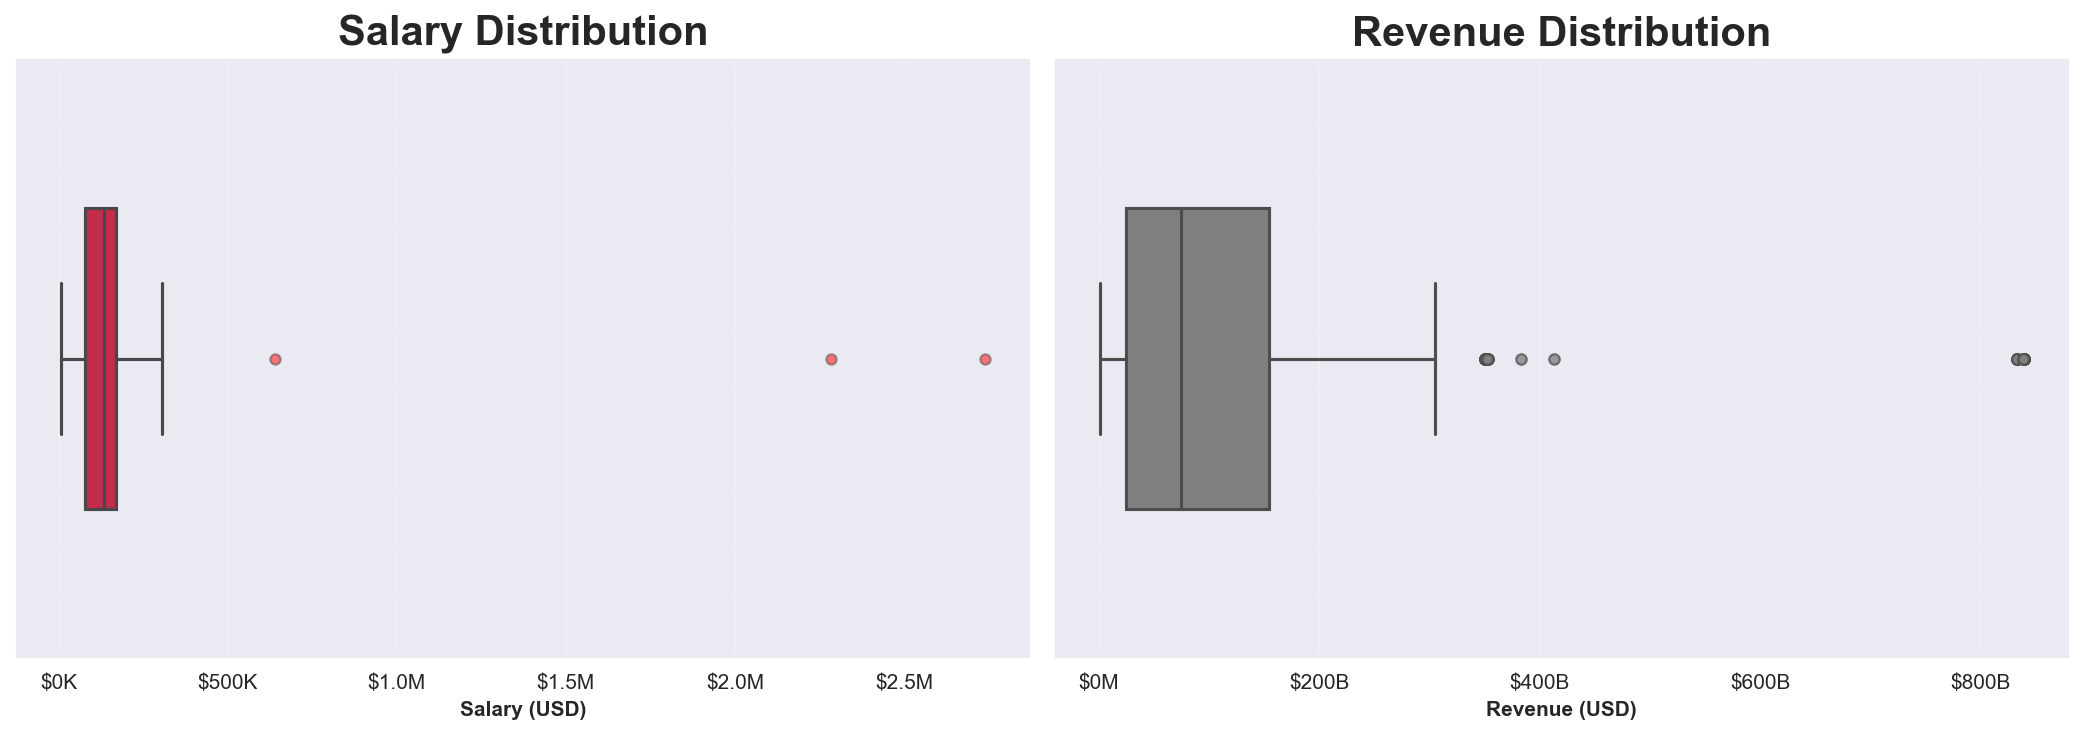

In [184]:
fig, axes = plt.subplots(figsize=(14, 5), nrows=1, ncols=2)

sns.boxplot(
    x=df['midpoint_salary'], 
    ax=axes[0],
    color='#DC143C',
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)
)

axes[0].set_title('Salary Distribution', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[0].set_xlabel('Salary (USD)', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[0].tick_params(axis='both', labelsize=10)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

sns.boxplot(
    x=df['revenue'], 
    ax=axes[1],
    color='#808080',
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5)
)

axes[1].set_title('Revenue Distribution', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[1].set_xlabel('Revenue (USD)', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.0f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

## Research Questions

1. How do salaries vary across different seniority levels?
2. Is there a relationship between company size/revenue and salary offerings?
3. What are the top skills requested across all job postings?
4. How does location correlate with salary ranges?
5. Which industries are hiring the most data scientists?
6. Does company ownership type affect hiring patterns?


<h3>1. How do salaries vary across different seniority levels?</h3>

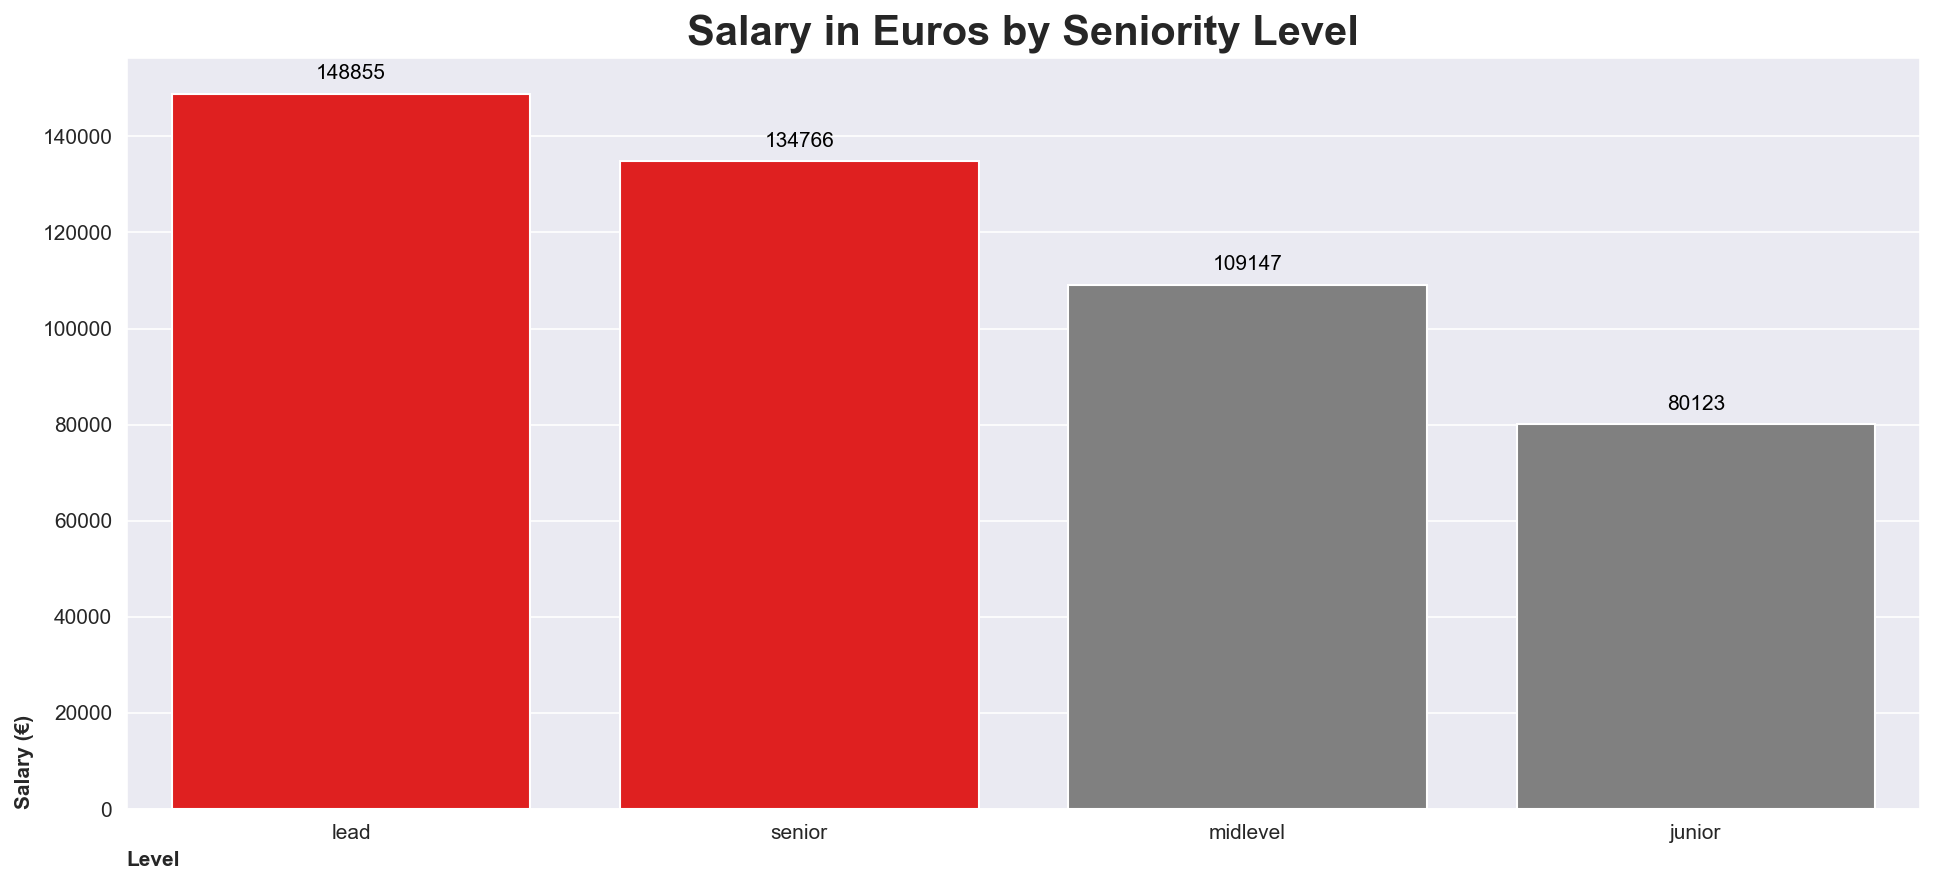

In [185]:
salary_by_seniority = (df.groupby('seniority_level', as_index=False)['midpoint_salary']
                       .median()
                       .sort_values(by='midpoint_salary', ascending=False)
                       .assign(color=lambda x: x['midpoint_salary']
                               .isin(x['midpoint_salary'].nlargest(2))
                               .map({True: 'red', False: 'gray'})))

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=salary_by_seniority, 
    x='seniority_level', y='midpoint_salary',
    ax=ax, 
    legend=False,
    hue='color',
    palette={
        'red': 'red',
        'gray': 'gray'
    }
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(int(height), ((p.get_x() + p.get_width() / 2), height),
                    ha='center', va='bottom', fontsize=LABELS_FONT_SIZE, color="black", xytext=(0,5), textcoords="offset points")

ax.set_title('Salary in Euros by Seniority Level', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Level', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Salary (€)', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

<p>Analysis shows a clear correlation between seniority level and salary in data science roles. Lead positions command the highest median salary at €148,855, followed by Senior roles at €134,766. There’s a notable salary gap of approximately €25k between Senior and Midlevel positions (€109,147), and another significant drop to Junior level at €80,123. The progression demonstrates that advancing from Junior to Lead level nearly doubles the compensation, with Lead positions earning 86% more than Junior roles. The highlighted top two tiers (Lead and Senior) represent the premium salary brackets in the data science job market.</p>

<h3>2. Is there a relationship between company size/revenue and salary offerings?</h3>

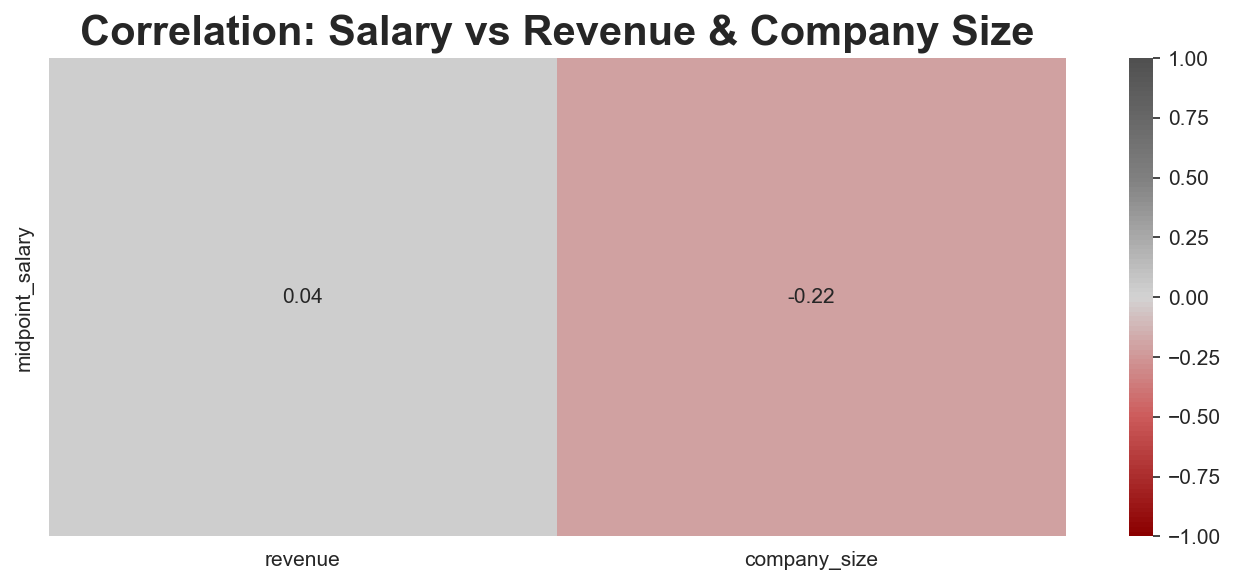

In [186]:
rev_size_salary_df = df[['midpoint_salary', 'revenue', 'company_size']].dropna()
correlation = rev_size_salary_df.corr()
salary_corr = correlation.loc[['midpoint_salary'], ['revenue', 'company_size']]

colors = ['#8B0000', '#CD5C5C', '#D3D3D3', '#808080', '#505050']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('red_gray', colors, N=n_bins)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(salary_corr, annot=True, fmt='.2f', cmap=cmap, vmin=-1, vmax=1)

ax.set_title('Correlation: Salary vs Revenue & Company Size', 
             fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

<p>Company revenue and size show weak correlations with salary, indicating that company financials are poor predictors of data science compensation. Other factors such as location, seniority, and industry appear to have stronger influences on salary levels than organizational scale or revenue.</p>


<h3>3. What are the top skills requested across all job postings?</h3>

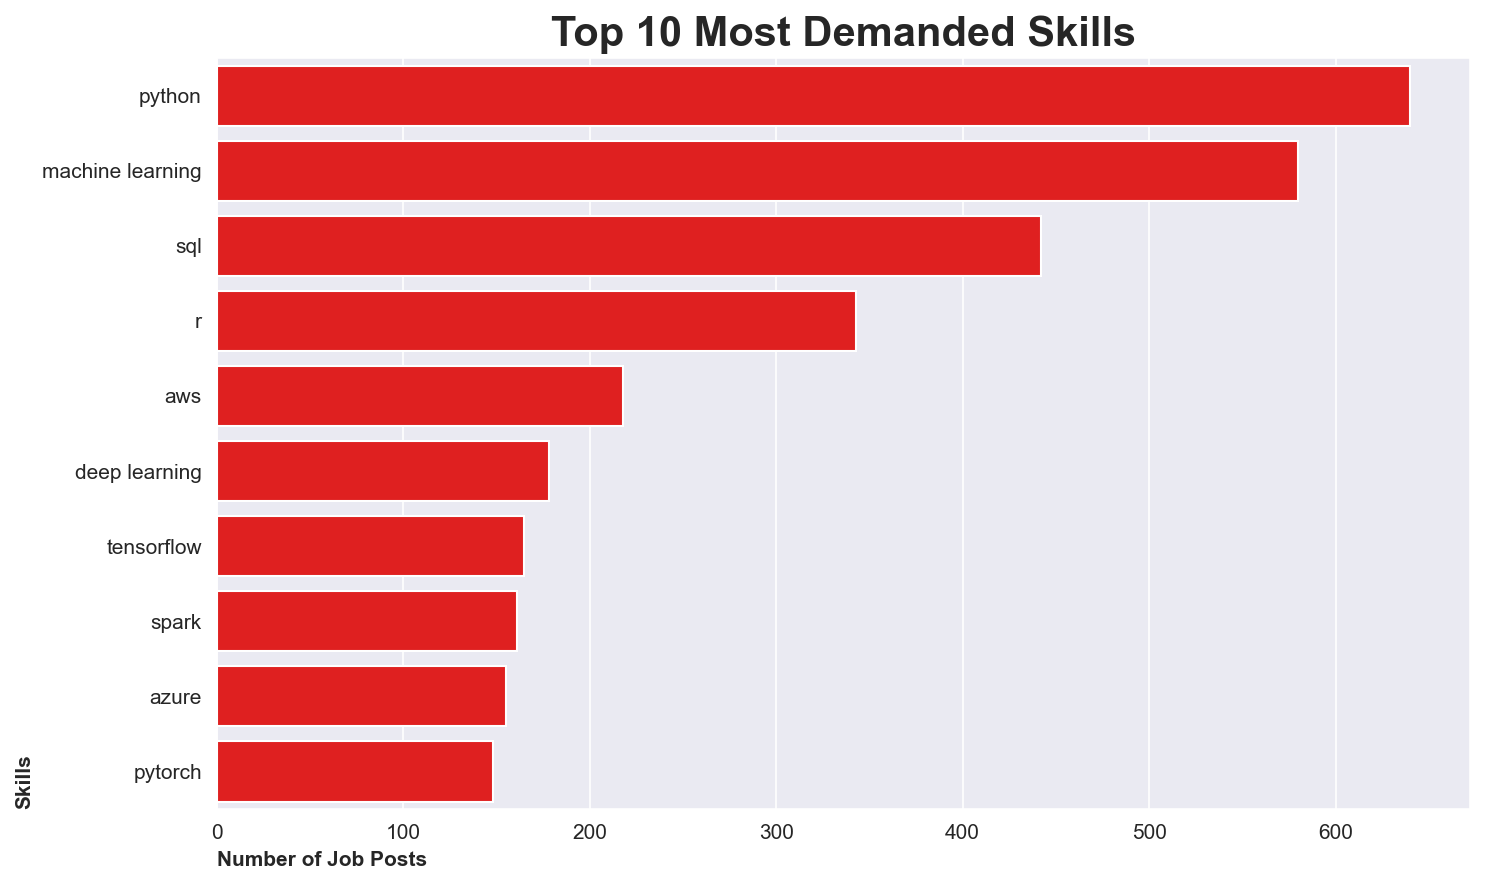

In [187]:
all_skills = []

def extract_skills(skills_str):
    try:
        skills = ast.literal_eval(skills_str)
        if skills:
            all_skills.extend(set(skills))
    except:
        pass

df['skills'].apply(extract_skills)

skills_df = (pd.Series(all_skills)
             .value_counts()
             .sort_values(ascending=False)
             .reset_index().rename(columns={'index': 'skill'}))


top_skills = skills_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_skills,
    y='skill',
    x='count',
    ax=ax,
    color='red'
)

ax.set_title('Top 10 Most Demanded Skills', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Number of Job Posts', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Skills', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

<p>Python dominates the skills landscape with 640 job postings, followed by machine learning (580) and SQL (450), establishing these three as essential competencies for data science roles. The programming language R remains relevant with 340 mentions, while cloud platforms AWS and Azure show strong demand at 220 and 150 postings respectively. Deep learning frameworks (TensorFlow, PyTorch) and big data tools (Spark) each appear in 140-170 positions, indicating that while foundational skills are critical, specialized knowledge in advanced machine learning and cloud technologies increasingly differentiates competitive candidates.</p>

<h3>4. How does location correlate with salary ranges?</h3>

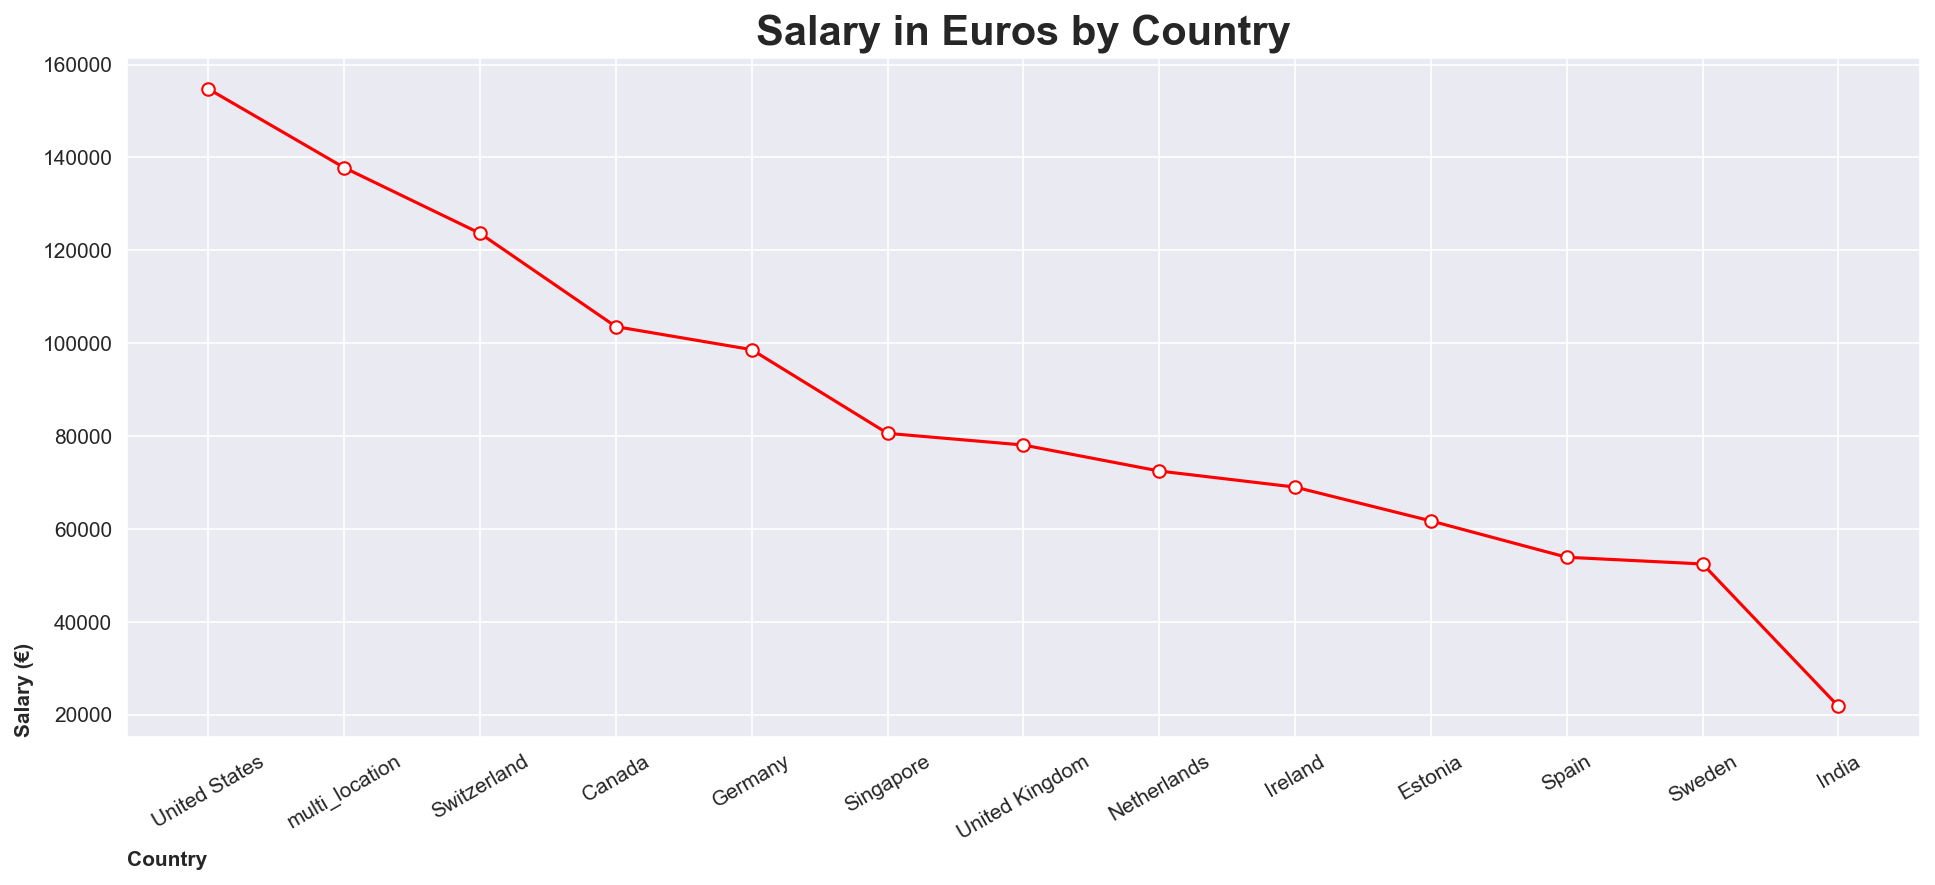

In [188]:
salary_by_country = (df.groupby('country', as_index=False)['midpoint_salary']
                     .median()
                     .sort_values(by='midpoint_salary', ascending=False))

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=salary_by_country, 
    x='country', y='midpoint_salary',
    ax=ax,
    color='red',
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='red',
    markeredgewidth=1, 
)


ax.set_title('Salary in Euros by Country', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Country', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Salary (€)', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<p>Geographic location significantly impacts data science compensation, with salaries ranging from €155,000 in the United States to just €20,000 in India—a nearly 8x difference. Western European countries (Switzerland, Germany) and North America dominate the upper salary bands (€100,000+), while Eastern European and Asian markets show considerably lower compensation levels. This stark variation reflects differences in purchasing power, economic maturity, and the supply-demand dynamics of tech talent across regions.</p>


<h3>5. Which industries are hiring the most data scientists?</h3>

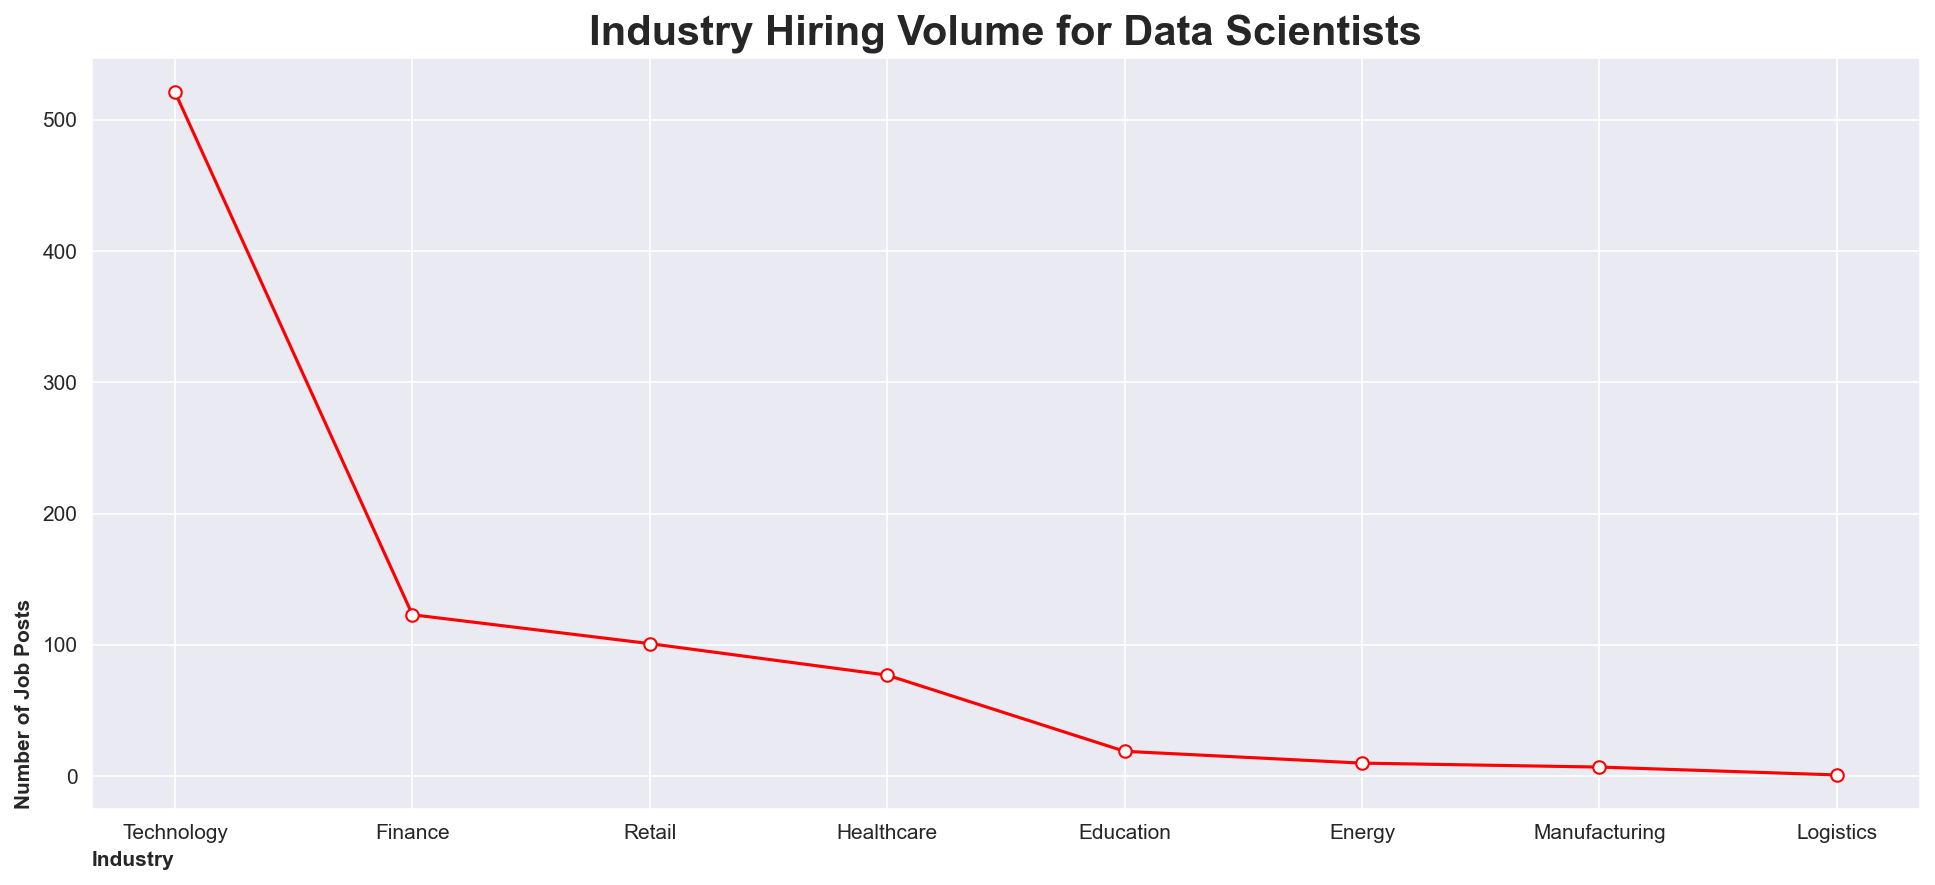

In [189]:
hiring_count_by_industry = (df.query('job_title == "data scientist"')
                            .groupby(['industry', 'job_title'], as_index=False)
                            .agg(count=('job_title', 'count'))
                            .sort_values(by='count', ascending=False)
                            .assign(color=lambda x: x['count']
                                   .isin(x['count'].nlargest(3))
                                   .map({True: 'red', False: 'gray'})))

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=hiring_count_by_industry, 
    x='industry', y='count',
    ax=ax,
    color='red',
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='red',
    markeredgewidth=1, 
)

ax.set_title('Industry Hiring Volume for Data Scientists', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Industry', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Number of Job Posts', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

<p>The Technology industry dominates data scientist hiring with over 500 job postings, representing more than three times the volume of any other sector. Finance and Retail follow as secondary markets with 150 and 120 postings respectively. Traditional industries like Manufacturing, Logistics, Energy, and Education show significantly lower demand, each with fewer than 50 positions, indicating that data science adoption remains concentrated in tech-forward sectors.</p>


<h3>6. Does company ownership type affect hiring patterns?</h3>

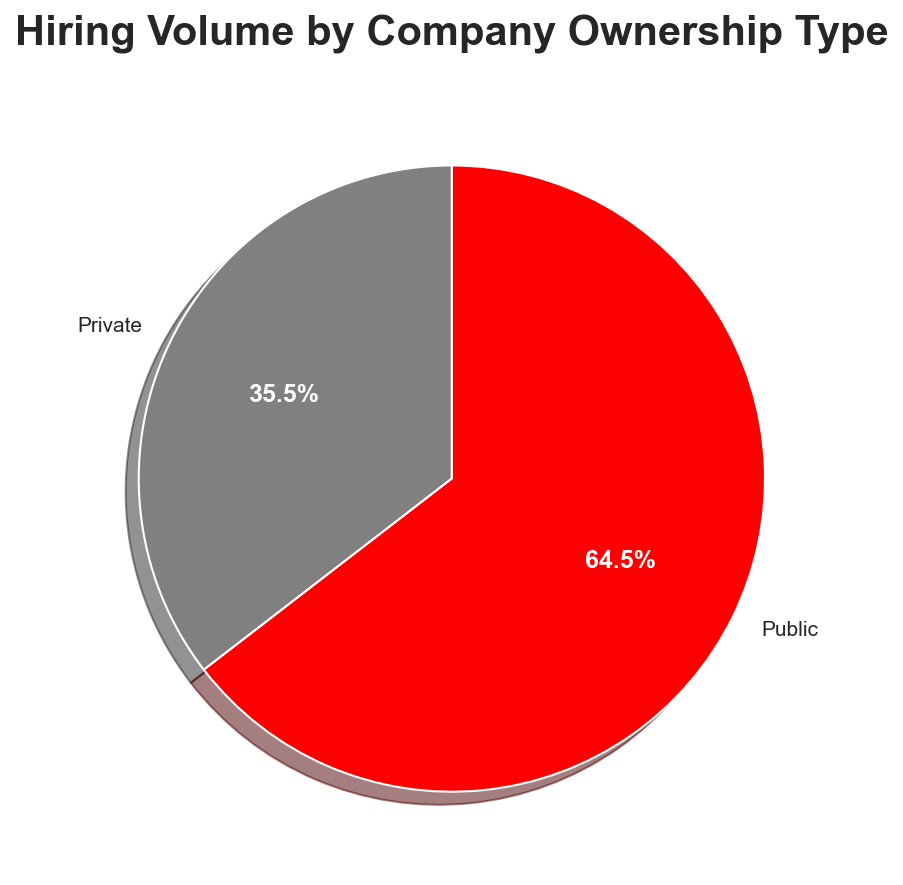

In [190]:
hiring_by_ownership = df.groupby('ownership', as_index=False).agg(count=('job_title', 'count'))

fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, auto_texts = ax.pie(
    hiring_by_ownership['count'],
    labels=hiring_by_ownership['ownership'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['gray', 'red'],
    shadow=True
)

for autotext in auto_texts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Hiring Volume by Company Ownership Type', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT, pad=20)
plt.tight_layout()
plt.show()

<p>Public companies dominate data science hiring, accounting for 64.5% of all job postings compared to 35.5% from private companies. This nearly 2:1 ratio suggests publicly-traded organizations have greater capacity and urgency for talent acquisition, likely driven by larger budgets, broader growth initiatives, and more extensive team structures. Private companies, while posting fewer positions, may be hiring more strategically based on specific project needs or funding constraints.</p>
